In [4]:
import pandas as pd
import numpy as np

data = []

for i in range(15000):
    # 🎯 Base mood pattern
    base = np.random.uniform(0.2, 0.9)

    # 📊 Generate 7-day mood
    mood_scores = base + np.random.normal(0, 0.1, 7)
    mood_scores = np.clip(mood_scores, 0, 1)

    # ⚠️ Add outliers (5% chance)
    if np.random.rand() < 0.05:
        idx = np.random.randint(0, 7)
        mood_scores[idx] = np.random.choice([0, 1])

    # 🧠 Compute hidden features (NOT saved)
    avg_mood = np.mean(mood_scores)
    trend = mood_scores[-1] - mood_scores[0]

    # 🎯 Label (based only on d1–d7 internally)
    if avg_mood < 0.3 and trend < 0:
        risk = 2   # HIGH
    elif avg_mood < 0.6:
        risk = 1   # MEDIUM
    else:
        risk = 0   # LOW

    # ✅ Store ONLY d1–d7 + label
    data.append(list(mood_scores) + [risk])

df = pd.DataFrame(data, columns=[
    "d1","d2","d3","d4","d5","d6","d7","risk"
])

df.head(10)

,d1,d2,d3,d4,d5,d6,d7,risk
0,0.612839,0.912213,0.678647,0.762193,0.748453,0.693764,0.775687,0
1,0.450417,0.440486,0.360303,0.485819,0.287805,0.377040,0.320249,1
2,0.585187,0.577184,0.650398,0.674659,0.790931,0.670659,0.657686,0
3,0.436738,0.374558,0.315048,0.585872,0.416344,0.209926,0.474811,1
4,0.828839,0.767147,0.697102,0.762320,0.823093,0.874053,0.864858,0
5,1.000000,0.696984,0.810754,0.581861,0.553186,0.705522,0.685101,0
6,0.211522,0.561743,0.519624,0.580910,0.371542,0.299233,0.396312,1
7,0.461421,0.546021,0.483235,0.474183,0.595615,0.541102,0.397156,1
8,0.647458,0.464620,0.382977,0.584710,0.754107,0.588994,0.555266,1
9,0.223246,0.264772,0.358199,0.317347,0.242573,0.169788,0.164516,2


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df.drop("risk", axis=1)
y = df["risk"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = XGBClassifier()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9753333333333334
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1295
           1       0.98      0.97      0.98      1500
           2       0.90      0.93      0.92       205

    accuracy                           0.98      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.98      0.98      0.98      3000



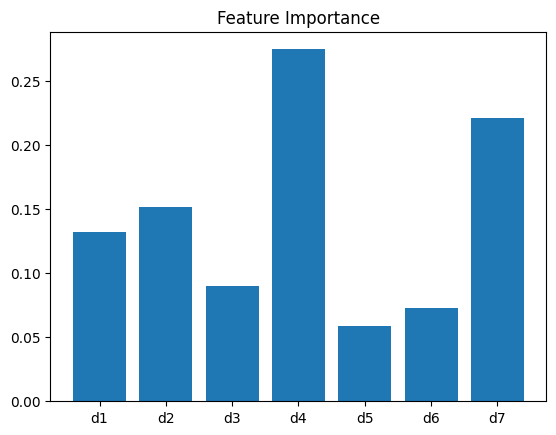

In [7]:
import matplotlib.pyplot as plt

# Feature importance
importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

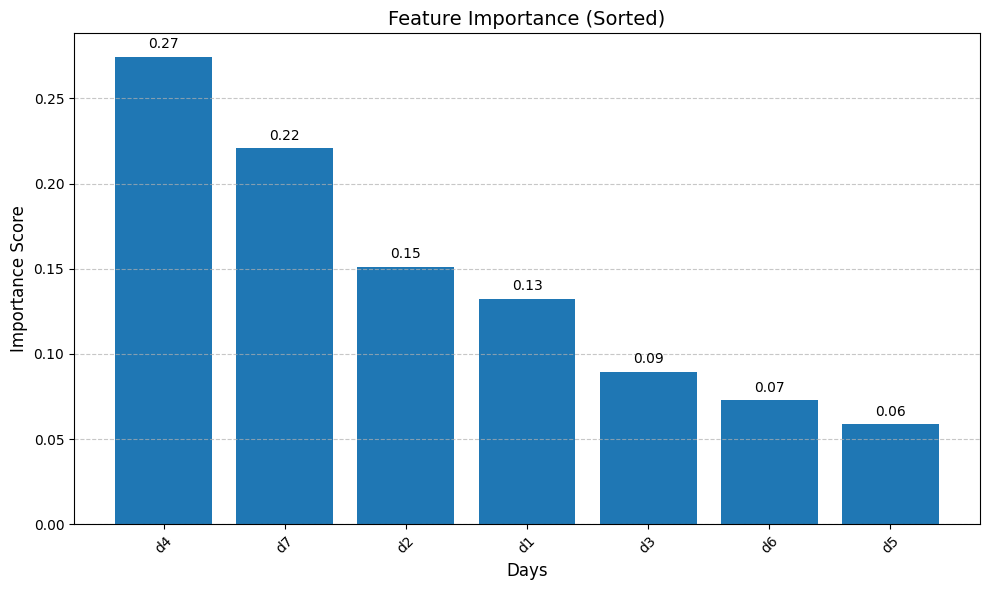

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get importance
importances = model.feature_importances_
features = X.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

sorted_features = features[indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_features, sorted_importances)

# Add values on top of bars
for i, v in enumerate(sorted_importances):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=10)

plt.title("Feature Importance (Sorted)", fontsize=14)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

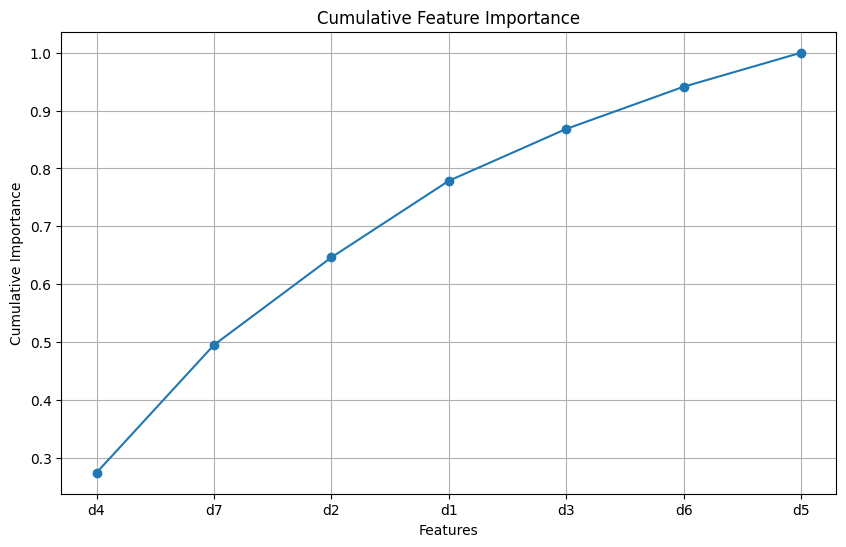

In [9]:
cumulative = np.cumsum(sorted_importances)

plt.figure(figsize=(10,6))
plt.plot(sorted_features, cumulative, marker='o')

plt.title("Cumulative Feature Importance")
plt.xlabel("Features")
plt.ylabel("Cumulative Importance")

plt.grid()
plt.show()

In [ ]:
import joblib
import os


# Save model
joblib.dump(model, "../data/mood_model.pkl")

print("✅ Model saved in ../data/mood_model.pkl")

✅ Model saved in ../data/mood_model.pkl
